# 04 — Feature Engineering

## Objective
Transform 80,000 weekly time-series rows into a 5,000-row
driver-level modeling dataset by computing behavioral
trajectory features, RFM signals, trend indicators, and
aggregations from support and incentive tables.

## The Core Transformation
Input  : 80,000 rows (16 weeks × 5,000 drivers)
Output : 5,000 rows (one per driver, all features)

## Feature Categories
1. RFM Features        — Recency, Frequency, Monetary
2. Trend Features      — Slope, direction, acceleration
3. Window Comparison   — Last 4 weeks vs first 8 weeks
4. Consistency Features— Gaps, streaks, volatility
5. Cancellation Trajectory — Rate change over time
6. Engagement Features — Login, hours, zones
7. Support Signals     — Tickets, disputes, resolution
8. Incentive Signals   — Offers, acceptance, value
9. Static Features     — Driver profile characteristics
10. Encoding           — Cyclicals, one-hot, target encoding

## Key New Concept: Panel-to-Cross-Section Transformation
Taking longitudinal (repeated measures) data and computing
summary statistics that capture behavioral trajectory.
This is different from all previous Feature Engineering —
we are not encoding existing columns, we are DERIVING
new columns from patterns across multiple rows per entity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

CHURN_COLORS = {0: "#4CAF50", 1: "#F44336"}
CHURN_LABELS = {0: "Retained", 1: "Churned"}

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

drivers_df   = pd.read_csv(PATH + "drivers_clean.csv",
                            parse_dates=["join_date"])
weekly_df    = pd.read_csv(PATH + "weekly_activity_clean.csv",
                            parse_dates=["week_start_date"])
incentive_df = pd.read_csv(PATH + "incentives_clean.csv")
tickets_df   = pd.read_csv(PATH + "support_tickets_clean.csv")

# Active window only (weeks 1-12) for feature computation
# Weeks 13-16 are the observation window — using them
# to compute features would be data leakage
active_df = weekly_df[
    weekly_df["week_number"].between(1, 12)
].copy()

# Pre-churn window (weeks 9-12) — last 4 active weeks
prechurn_df = weekly_df[
    weekly_df["week_number"].between(9, 12)
].copy()

# Early window (weeks 1-8) — baseline behavior
early_df = weekly_df[
    weekly_df["week_number"].between(1, 8)
].copy()

print("Data loaded ✅")
print(f"  Full weekly data  : {weekly_df.shape}")
print(f"  Active window     : {active_df.shape} "
      f"(weeks 1-12 — features computed here)")
print(f"  Early window      : {early_df.shape} "
      f"(weeks 1-8 — baseline)")
print(f"  Pre-churn window  : {prechurn_df.shape} "
      f"(weeks 9-12 — trajectory end)")
print(f"\nTarget: is_churned")
print(f"  Churned  : {drivers_df['is_churned'].sum():,}")
print(f"  Retained : {(drivers_df['is_churned']==0).sum():,}")

Data loaded ✅
  Full weekly data  : (80000, 17)
  Active window     : (60000, 17) (weeks 1-12 — features computed here)
  Early window      : (40000, 17) (weeks 1-8 — baseline)
  Pre-churn window  : (20000, 17) (weeks 9-12 — trajectory end)

Target: is_churned
  Churned  : 2,015
  Retained : 2,985


## Critical Leakage Warning for This Notebook

### What Is Allowed
Computing features from weeks 1-12 only.
The model predicts: "Given what I know about weeks 1-12,
will this driver be active in weeks 13-16?"

### What Is NOT Allowed
1. Using weeks 13-16 for any feature computation
   (those weeks determine the label)

2. Using `will_churn` column from weekly_activity
   (this is the generator's internal label — in production
   it would not exist. It is equivalent to using the
   target variable as a feature)

3. Using `churn_reason` column
   (only known after churn occurs — post-hoc information)

4. Using any column from weeks 13-16
   (future data relative to prediction time)

### Production Framing
In production, Ola would run this model at the END of
week 12. At that moment, only weeks 1-12 data exists.
Weeks 13-16 have not happened yet. We simulate this
exactly by computing ALL features from weeks 1-12 only.

## Step 1 — RFM Features

### Recency
How recently was the driver active?
The most powerful single predictor in almost every
churn model ever built.

Operationally: last week with rides > 0, measured
backward from end of week 12.
A retained driver: last_active = week 12 → recency = 0
A churning driver: last_active = week 8 → recency = 4

### Frequency
How consistently was the driver completing rides?
Mean rides per week over the active window.
Also: total rides, and frequency in each sub-window.

### Monetary
How much did the driver earn over the active window?
Total earnings and mean weekly earnings.
Drivers with higher earnings have more financial
incentive to stay — lower churn risk all else equal.

In [3]:
modeling_df = drivers_df[
    ["driver_id","is_churned","vehicle_type","churn_profile",
     "rating","age","experience_years","days_on_platform",
     "zones_known","has_other_income","uses_competitor_app",
     "bank_account_linked","is_prime_driver","referral_source",
     "gender"]
].copy()

print("Building RFM features...\n")

# ── Recency ───────────────────────────────────────────────────
last_active = active_df[
    active_df["rides_this_week"] > 0
].groupby("driver_id")["week_number"].max().reset_index()
last_active.columns = ["driver_id", "last_active_week"]

modeling_df = modeling_df.merge(last_active, on="driver_id", how="left")
modeling_df["last_active_week"] = modeling_df[
    "last_active_week"
].fillna(0)
modeling_df["weeks_since_last_ride"] = (
    12 - modeling_df["last_active_week"]
)

print(f"  last_active_week        : computed ✅")
print(f"  weeks_since_last_ride   : computed ✅")

# ── Frequency ─────────────────────────────────────────────────
freq_features = active_df.groupby("driver_id").agg(
    total_rides_active        = ("rides_this_week", "sum"),
    mean_rides_per_week       = ("rides_this_week", "mean"),
    median_rides_per_week     = ("rides_this_week", "median"),
    max_rides_single_week     = ("rides_this_week", "max"),
    std_rides_per_week        = ("rides_this_week", "std"),
    weeks_zero_rides          = ("rides_this_week",
                                  lambda x: (x==0).sum()),
    weeks_above_20_rides      = ("rides_this_week",
                                  lambda x: (x>20).sum()),
).reset_index()

modeling_df = modeling_df.merge(freq_features, on="driver_id", how="left")
print(f"  Frequency features      : {len(freq_features.columns)-1} computed ✅")

# ── Monetary ──────────────────────────────────────────────────
money_features = active_df.groupby("driver_id").agg(
    total_earnings_active     = ("weekly_earnings", "sum"),
    mean_weekly_earnings      = ("weekly_earnings", "mean"),
    std_weekly_earnings       = ("weekly_earnings", "std"),
    max_weekly_earnings       = ("weekly_earnings", "max"),
    min_weekly_earnings       = ("weekly_earnings", "min"),
).reset_index()

modeling_df = modeling_df.merge(money_features, on="driver_id", how="left")
print(f"  Monetary features       : {len(money_features.columns)-1} computed ✅")

print(f"\nModeling dataset shape: {modeling_df.shape}")

Building RFM features...

  last_active_week        : computed ✅
  weeks_since_last_ride   : computed ✅
  Frequency features      : 7 computed ✅
  Monetary features       : 5 computed ✅

Modeling dataset shape: (5000, 29)


In [4]:
print("Building trend features (slope analysis)...\n")

def compute_ride_slope(series):
    """Linear trend slope of weekly ride counts."""
    weeks  = np.arange(1, len(series) + 1)
    values = np.array(series.values, dtype=float)
    if len(values) < 3 or np.std(values) == 0:
        return 0.0
    coeffs = np.polyfit(weeks, values, 1)
    return round(float(coeffs[0]), 4)

def compute_earnings_slope(series):
    """Linear trend slope of weekly earnings."""
    weeks  = np.arange(1, len(series) + 1)
    values = np.array(series.values, dtype=float)
    if len(values) < 3 or np.std(values) == 0:
        return 0.0
    coeffs = np.polyfit(weeks, values, 1)
    return round(float(coeffs[0]), 4)

# Ride slope
ride_slope = active_df.groupby("driver_id")[
    "rides_this_week"
].apply(compute_ride_slope).reset_index()
ride_slope.columns = ["driver_id", "ride_slope"]

# Earnings slope
earnings_slope = active_df.groupby("driver_id")[
    "weekly_earnings"
].apply(compute_earnings_slope).reset_index()
earnings_slope.columns = ["driver_id", "earnings_slope"]

# Cancel rate slope
cancel_slope = active_df.groupby("driver_id")[
    "cancellation_rate"
].apply(compute_ride_slope).reset_index()
cancel_slope.columns = ["driver_id", "cancel_slope"]

# Hours slope
hours_slope = active_df.groupby("driver_id")[
    "hours_online"
].apply(compute_ride_slope).reset_index()
hours_slope.columns = ["driver_id", "hours_slope"]

# Merge all slopes
for slope_df in [ride_slope, earnings_slope,
                 cancel_slope, hours_slope]:
    modeling_df = modeling_df.merge(
        slope_df, on="driver_id", how="left"
    )

print(f"  ride_slope     : computed ✅  "
      f"(churned mean: {ride_slope.merge(drivers_df[['driver_id','is_churned']])['ride_slope'][drivers_df['is_churned']==1].mean():.3f})")
print(f"  earnings_slope : computed ✅")
print(f"  cancel_slope   : computed ✅")
print(f"  hours_slope    : computed ✅")
print(f"\nModeling dataset shape: {modeling_df.shape}")

Building trend features (slope analysis)...

  ride_slope     : computed ✅  (churned mean: -2.947)
  earnings_slope : computed ✅
  cancel_slope   : computed ✅
  hours_slope    : computed ✅

Modeling dataset shape: (5000, 33)


In [5]:
print("Building window comparison features...\n")

# Early window (weeks 1-8) aggregations
early_agg = early_df.groupby("driver_id").agg(
    mean_rides_early    = ("rides_this_week", "mean"),
    mean_earnings_early = ("weekly_earnings", "mean"),
    mean_cancel_early   = ("cancellation_rate", "mean"),
    mean_hours_early    = ("hours_online", "mean"),
    mean_login_early    = ("login_days", "mean"),
).reset_index()

# Pre-churn window (weeks 9-12) aggregations
prechurn_agg = prechurn_df.groupby("driver_id").agg(
    mean_rides_last4    = ("rides_this_week", "mean"),
    mean_earnings_last4 = ("weekly_earnings", "mean"),
    mean_cancel_last4   = ("cancellation_rate", "mean"),
    mean_hours_last4    = ("hours_online", "mean"),
    mean_login_last4    = ("login_days", "mean"),
).reset_index()

modeling_df = modeling_df.merge(early_agg,    on="driver_id", how="left")
modeling_df = modeling_df.merge(prechurn_agg, on="driver_id", how="left")

# Compute RATIOS: last4 / early (the activity ratio from EDA)
def safe_ratio(num, denom, fill=0.0):
    return np.where(denom > 0, num / denom, fill)

modeling_df["rides_ratio"] = safe_ratio(
    modeling_df["mean_rides_last4"],
    modeling_df["mean_rides_early"]
)
modeling_df["earnings_ratio"] = safe_ratio(
    modeling_df["mean_earnings_last4"],
    modeling_df["mean_earnings_early"]
)
modeling_df["cancel_ratio"] = safe_ratio(
    modeling_df["mean_cancel_last4"],
    modeling_df["mean_cancel_early"]
)
modeling_df["hours_ratio"] = safe_ratio(
    modeling_df["mean_hours_last4"],
    modeling_df["mean_hours_early"]
)

# Compute DIFFERENCES: last4 - early
modeling_df["rides_change"]    = (
    modeling_df["mean_rides_last4"] -
    modeling_df["mean_rides_early"]
)
modeling_df["earnings_change"] = (
    modeling_df["mean_earnings_last4"] -
    modeling_df["mean_earnings_early"]
)
modeling_df["cancel_change"]   = (
    modeling_df["mean_cancel_last4"] -
    modeling_df["mean_cancel_early"]
)

print("Window comparison features computed ✅")
print(f"\n  Activity ratio by churn status:")
temp = modeling_df.merge(
    drivers_df[["driver_id","is_churned"]], on="driver_id"
) if "is_churned" not in modeling_df.columns else modeling_df

for k in [0, 1]:
    mean_ratio = modeling_df[
        modeling_df["is_churned"]==k
    ]["rides_ratio"].mean()
    print(f"    {CHURN_LABELS[k]:<12}: {mean_ratio:.4f}")

print(f"\nModeling dataset shape: {modeling_df.shape}")

Building window comparison features...

Window comparison features computed ✅

  Activity ratio by churn status:
    Retained    : 1.0873
    Churned     : 0.1418

Modeling dataset shape: (5000, 50)


In [6]:
print("Building behavioral consistency features...\n")

def max_consecutive_zeros(series):
    """Find the longest streak of zero-ride weeks."""
    max_streak = 0
    current    = 0
    for val in series:
        if val == 0:
            current += 1
            max_streak = max(max_streak, current)
        else:
            current = 0
    return max_streak

consistency_features = active_df.groupby("driver_id").apply(
    lambda g: pd.Series({
        "max_consecutive_zero_weeks": max_consecutive_zeros(
            g.sort_values("week_number")["rides_this_week"]
        ),
        "weeks_active_pct": (
            g["rides_this_week"] > 0
        ).mean(),
        "login_consistency": (
            g["login_days"] > 0
        ).mean(),
        "income_volatility_cv": (
            g["weekly_earnings"].std() /
            g["weekly_earnings"].mean()
            if g["weekly_earnings"].mean() > 0 else 0
        ),
        "rides_gini": (
            g["rides_this_week"].std() /
            g["rides_this_week"].mean()
            if g["rides_this_week"].mean() > 0 else 1.0
        ),
    })
).reset_index()

modeling_df = modeling_df.merge(
    consistency_features, on="driver_id", how="left"
)

print("Consistency features computed ✅")
print(f"  max_consecutive_zero_weeks : longest idle streak")
print(f"  weeks_active_pct           : % of weeks with rides")
print(f"  login_consistency          : % of weeks with logins")
print(f"  income_volatility_cv       : earnings coefficient of variation")
print(f"  rides_gini                 : rides coefficient of variation")
print(f"\nModeling dataset shape: {modeling_df.shape}")

Building behavioral consistency features...

Consistency features computed ✅
  max_consecutive_zero_weeks : longest idle streak
  weeks_active_pct           : % of weeks with rides
  login_consistency          : % of weeks with logins
  income_volatility_cv       : earnings coefficient of variation
  rides_gini                 : rides coefficient of variation

Modeling dataset shape: (5000, 55)


In [7]:
print("Building support ticket features...\n")

# Only tickets from the active window (weeks 1-12)
tickets_active = tickets_df[
    tickets_df["ticket_week"].between(1, 12)
].copy()

# Count by category
cat_pivot = tickets_active.pivot_table(
    index="driver_id",
    columns="category",
    values="ticket_week",
    aggfunc="count",
    fill_value=0
).reset_index()

# Rename columns
cat_pivot.columns = (
    ["driver_id"] +
    [f"tickets_{c}" for c in cat_pivot.columns[1:]]
)

# Summary ticket features
ticket_summary = tickets_active.groupby("driver_id").agg(
    total_tickets        = ("category", "count"),
    unresolved_tickets   = ("resolution",
        lambda x: (x=="pending").sum()),
    earnings_complaints  = ("category",
        lambda x: (x=="earnings_dispute").sum()),
    app_issues           = ("category",
        lambda x: (x=="app_technical").sum()),
    avg_satisfaction     = ("satisfaction", "mean"),
    avg_resolution_days  = ("resolution_days", "mean"),
    has_safety_concern   = ("category",
        lambda x: int((x=="safety_concern").any())),
).reset_index()

ticket_summary["unresolved_ticket_rate"] = (
    ticket_summary["unresolved_tickets"] /
    ticket_summary["total_tickets"].replace(0, np.nan)
).fillna(0)

# Merge
modeling_df = modeling_df.merge(
    ticket_summary, on="driver_id", how="left"
)
# Fill zero for drivers with no tickets
ticket_fill_cols = [c for c in ticket_summary.columns
                    if c != "driver_id"]
for col in ticket_fill_cols:
    if col in modeling_df.columns:
        if col == "avg_satisfaction":
            modeling_df[col] = modeling_df[col].fillna(
                modeling_df[col].median()
            )
        else:
            modeling_df[col] = modeling_df[col].fillna(0)

print("Support ticket features computed ✅")
print(f"  total_tickets              : total complaints")
print(f"  earnings_complaints        : earnings dispute tickets")
print(f"  unresolved_ticket_rate     : % unresolved (frustration)")
print(f"  has_safety_concern         : binary safety flag")
print(f"  avg_satisfaction           : resolved ticket satisfaction")
print(f"\nModeling dataset shape: {modeling_df.shape}")

Building support ticket features...

Support ticket features computed ✅
  total_tickets              : total complaints
  earnings_complaints        : earnings dispute tickets
  unresolved_ticket_rate     : % unresolved (frustration)
  has_safety_concern         : binary safety flag
  avg_satisfaction           : resolved ticket satisfaction

Modeling dataset shape: (5000, 63)


In [8]:
print("Building incentive features...\n")

# Active window incentives only
incentives_active = incentive_df[
    incentive_df["offer_week"].between(1, 12)
].copy()

incentive_summary = incentives_active.groupby("driver_id").agg(
    total_incentive_offers   = ("offer_value", "count"),
    total_incentive_value    = ("offer_value", "sum"),
    incentive_acceptance_rate= ("was_accepted", "mean"),
    mean_offer_value         = ("offer_value", "mean"),
    received_retention_offer = ("incentive_type",
        lambda x: int((x=="retention_offer").any())),
    accepted_retention_offer = ("incentive_type",
        lambda x: int(
            any((x=="retention_offer") &
                (incentives_active.loc[x.index,"was_accepted"]))
        )),
).reset_index()

modeling_df = modeling_df.merge(
    incentive_summary, on="driver_id", how="left"
)

incentive_fill_cols = [c for c in incentive_summary.columns
                       if c != "driver_id"]
for col in incentive_fill_cols:
    if col in modeling_df.columns:
        modeling_df[col] = modeling_df[col].fillna(0)

print("Incentive features computed ✅")
print(f"  total_incentive_offers   : how many offers received")
print(f"  incentive_acceptance_rate: engagement with platform offers")
print(f"  received_retention_offer : was platform already worried?")
print(f"  accepted_retention_offer : did intervention work?")
print(f"\nModeling dataset shape: {modeling_df.shape}")

Building incentive features...

Incentive features computed ✅
  total_incentive_offers   : how many offers received
  incentive_acceptance_rate: engagement with platform offers
  received_retention_offer : was platform already worried?
  accepted_retention_offer : did intervention work?

Modeling dataset shape: (5000, 69)


In [12]:
print("Building engagement features...\n")

engagement_features = active_df.groupby("driver_id").agg(
    mean_login_days     = ("login_days", "mean"),
    mean_hours_online   = ("hours_online", "mean"),
    mean_zones_covered  = ("zones_covered", "mean"),
    total_complaints    = ("complaints", "sum"),
    mean_surge_factor   = ("surge_factor", "mean"),
    mean_weekly_rating  = ("weekly_rating", "mean"),
    rating_trend        = ("weekly_rating",
        lambda x: (lambda y: float(np.polyfit(np.arange(len(y)), y, 1)[0])
                    if len(y) > 1 else 0.0)(x.ffill().dropna())
    ),
).reset_index()

modeling_df = modeling_df.merge(
    engagement_features, on="driver_id", how="left"
)

print("Engagement features computed ✅")
print(f"  mean_login_days    : app engagement")
print(f"  mean_hours_online  : time investment")
print(f"  rating_trend       : is rating improving or declining?")
print(f"  total_complaints   : frustration signals")
print(f"\nModeling dataset shape: {modeling_df.shape}")

Building engagement features...

Engagement features computed ✅
  mean_login_days    : app engagement
  mean_hours_online  : time investment
  rating_trend       : is rating improving or declining?
  total_complaints   : frustration signals

Modeling dataset shape: (5000, 76)


In [13]:
print("Encoding categorical features...\n")

# ── One-hot encode vehicle type ───────────────────────────────
vehicle_dummies = pd.get_dummies(
    modeling_df["vehicle_type"],
    prefix="vehicle", drop_first=True
)
modeling_df = pd.concat([modeling_df, vehicle_dummies], axis=1)
print(f"  vehicle_type one-hot: {vehicle_dummies.shape[1]} columns")

# ── One-hot encode gender ─────────────────────────────────────
modeling_df["gender"] = modeling_df["gender"].fillna("Not Specified")
gender_dummies = pd.get_dummies(
    modeling_df["gender"], prefix="gender", drop_first=True
)
modeling_df = pd.concat([modeling_df, gender_dummies], axis=1)
print(f"  gender one-hot      : {gender_dummies.shape[1]} columns")

# ── Target encode referral source by churn rate ───────────────
referral_churn_map = modeling_df.groupby(
    "referral_source"
)["is_churned"].mean()
modeling_df["referral_encoded"] = modeling_df[
    "referral_source"
].map(referral_churn_map)
modeling_df["referral_encoded"] = modeling_df[
    "referral_encoded"
].fillna(modeling_df["is_churned"].mean())
print(f"  referral_source target encoded by churn rate")

# ── Convert booleans to int ───────────────────────────────────
bool_cols = [
    "has_other_income", "uses_competitor_app",
    "bank_account_linked", "is_prime_driver"
]
for col in bool_cols:
    if col in modeling_df.columns:
        modeling_df[col] = modeling_df[col].astype(int)
print(f"  boolean → int conversion for {len(bool_cols)} columns")

print(f"\nModeling dataset shape: {modeling_df.shape}")

Encoding categorical features...

  vehicle_type one-hot: 4 columns
  gender one-hot      : 2 columns
  referral_source target encoded by churn rate
  boolean → int conversion for 4 columns

Modeling dataset shape: (5000, 83)


In [14]:
print("Building composite churn risk indicator...\n")

# Standardize key features to [0, 1] for scoring
def normalize(series):
    min_v = series.min()
    max_v = series.max()
    if max_v == min_v:
        return pd.Series(0.5, index=series.index)
    return (series - min_v) / (max_v - min_v)

# Each component: higher value = higher churn risk
modeling_df["risk_recency"] = normalize(
    modeling_df["weeks_since_last_ride"]
)
modeling_df["risk_frequency"] = 1 - normalize(
    modeling_df["mean_rides_per_week"]
)
modeling_df["risk_cancel"] = normalize(
    modeling_df["mean_cancel_rate_last4"]
    if "mean_cancel_rate_last4" in modeling_df.columns
    else modeling_df["mean_cancel_last4"]
)
modeling_df["risk_trend"] = 1 - normalize(
    modeling_df["rides_ratio"]
)
modeling_df["risk_tickets"] = normalize(
    modeling_df["unresolved_ticket_rate"]
)

# Composite score: weighted average of five components
# Weights based on EDA correlation rankings
modeling_df["churn_risk_score"] = (
    0.25 * modeling_df["risk_trend"] +       # activity ratio — strongest
    0.25 * modeling_df["risk_cancel"] +      # cancel rate — #1 corr
    0.20 * modeling_df["risk_recency"] +     # recency — RFM R
    0.15 * modeling_df["risk_frequency"] +   # frequency — RFM F
    0.15 * modeling_df["risk_tickets"]       # ticket frustration
)

# Validate: composite score should correlate strongly with churn
corr = modeling_df["churn_risk_score"].corr(
    modeling_df["is_churned"]
)
print(f"  churn_risk_score created ✅")
print(f"  Correlation with is_churned: {corr:.4f}")
print(f"\n  Mean score by churn status:")
for k in [0, 1]:
    mean_score = modeling_df[
        modeling_df["is_churned"]==k
    ]["churn_risk_score"].mean()
    print(f"    {CHURN_LABELS[k]:<12}: {mean_score:.4f}")

Building composite churn risk indicator...

  churn_risk_score created ✅
  Correlation with is_churned: 0.9027

  Mean score by churn status:
    Retained    : 0.2049
    Churned     : 0.6458


In [15]:
print("Assembling final feature matrix...\n")

TARGET = "is_churned"

# Columns to EXCLUDE from features
exclude_cols = [
    "driver_id",        # identifier
    "is_churned",       # target
    "churn_profile",    # generator label — not available in production
    "vehicle_type",     # raw text — one-hot versions used
    "gender",           # raw text — one-hot version used
    "referral_source",  # raw text — encoded version used
    "join_date",        # datetime — days_on_platform used instead
]

# Get all numeric columns except excluded
feature_cols = [
    c for c in modeling_df.columns
    if c not in exclude_cols
    and modeling_df[c].dtype in [
        np.float64, np.int64, np.float32, np.int32, bool
    ]
    and c != TARGET
]

# Build final modeling dataset
X = modeling_df[feature_cols].copy()
y = modeling_df[TARGET].copy()

# Drop any remaining nulls
before_rows = len(X)
valid_mask  = X.notna().all(axis=1)
X = X[valid_mask].reset_index(drop=True)
y = y[valid_mask].reset_index(drop=True)
after_rows  = len(X)

print(f"FINAL FEATURE MATRIX")
print(f"  Rows      : {len(X):,} "
      f"(dropped {before_rows-after_rows} rows with nulls)")
print(f"  Features  : {len(feature_cols)}")
print(f"  Target    : {TARGET}")
print(f"  Churn rate: {y.mean()*100:.2f}%")

print(f"\nFeature list ({len(feature_cols)} total):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

Assembling final feature matrix...

FINAL FEATURE MATRIX
  Rows      : 5,000 (dropped 0 rows with nulls)
  Features  : 83
  Target    : is_churned
  Churn rate: 40.30%

Feature list (83 total):
   1. rating
   2. age
   3. experience_years
   4. days_on_platform
   5. zones_known
   6. has_other_income
   7. uses_competitor_app
   8. bank_account_linked
   9. is_prime_driver
  10. last_active_week
  11. weeks_since_last_ride
  12. total_rides_active
  13. mean_rides_per_week
  14. median_rides_per_week
  15. max_rides_single_week
  16. std_rides_per_week
  17. weeks_zero_rides
  18. weeks_above_20_rides
  19. total_earnings_active
  20. mean_weekly_earnings
  21. std_weekly_earnings
  22. max_weekly_earnings
  23. min_weekly_earnings
  24. ride_slope
  25. earnings_slope
  26. cancel_slope
  27. hours_slope
  28. mean_rides_early
  29. mean_earnings_early
  30. mean_cancel_early
  31. mean_hours_early
  32. mean_login_early
  33. mean_rides_last4
  34. mean_earnings_last4
  35. mean_ca

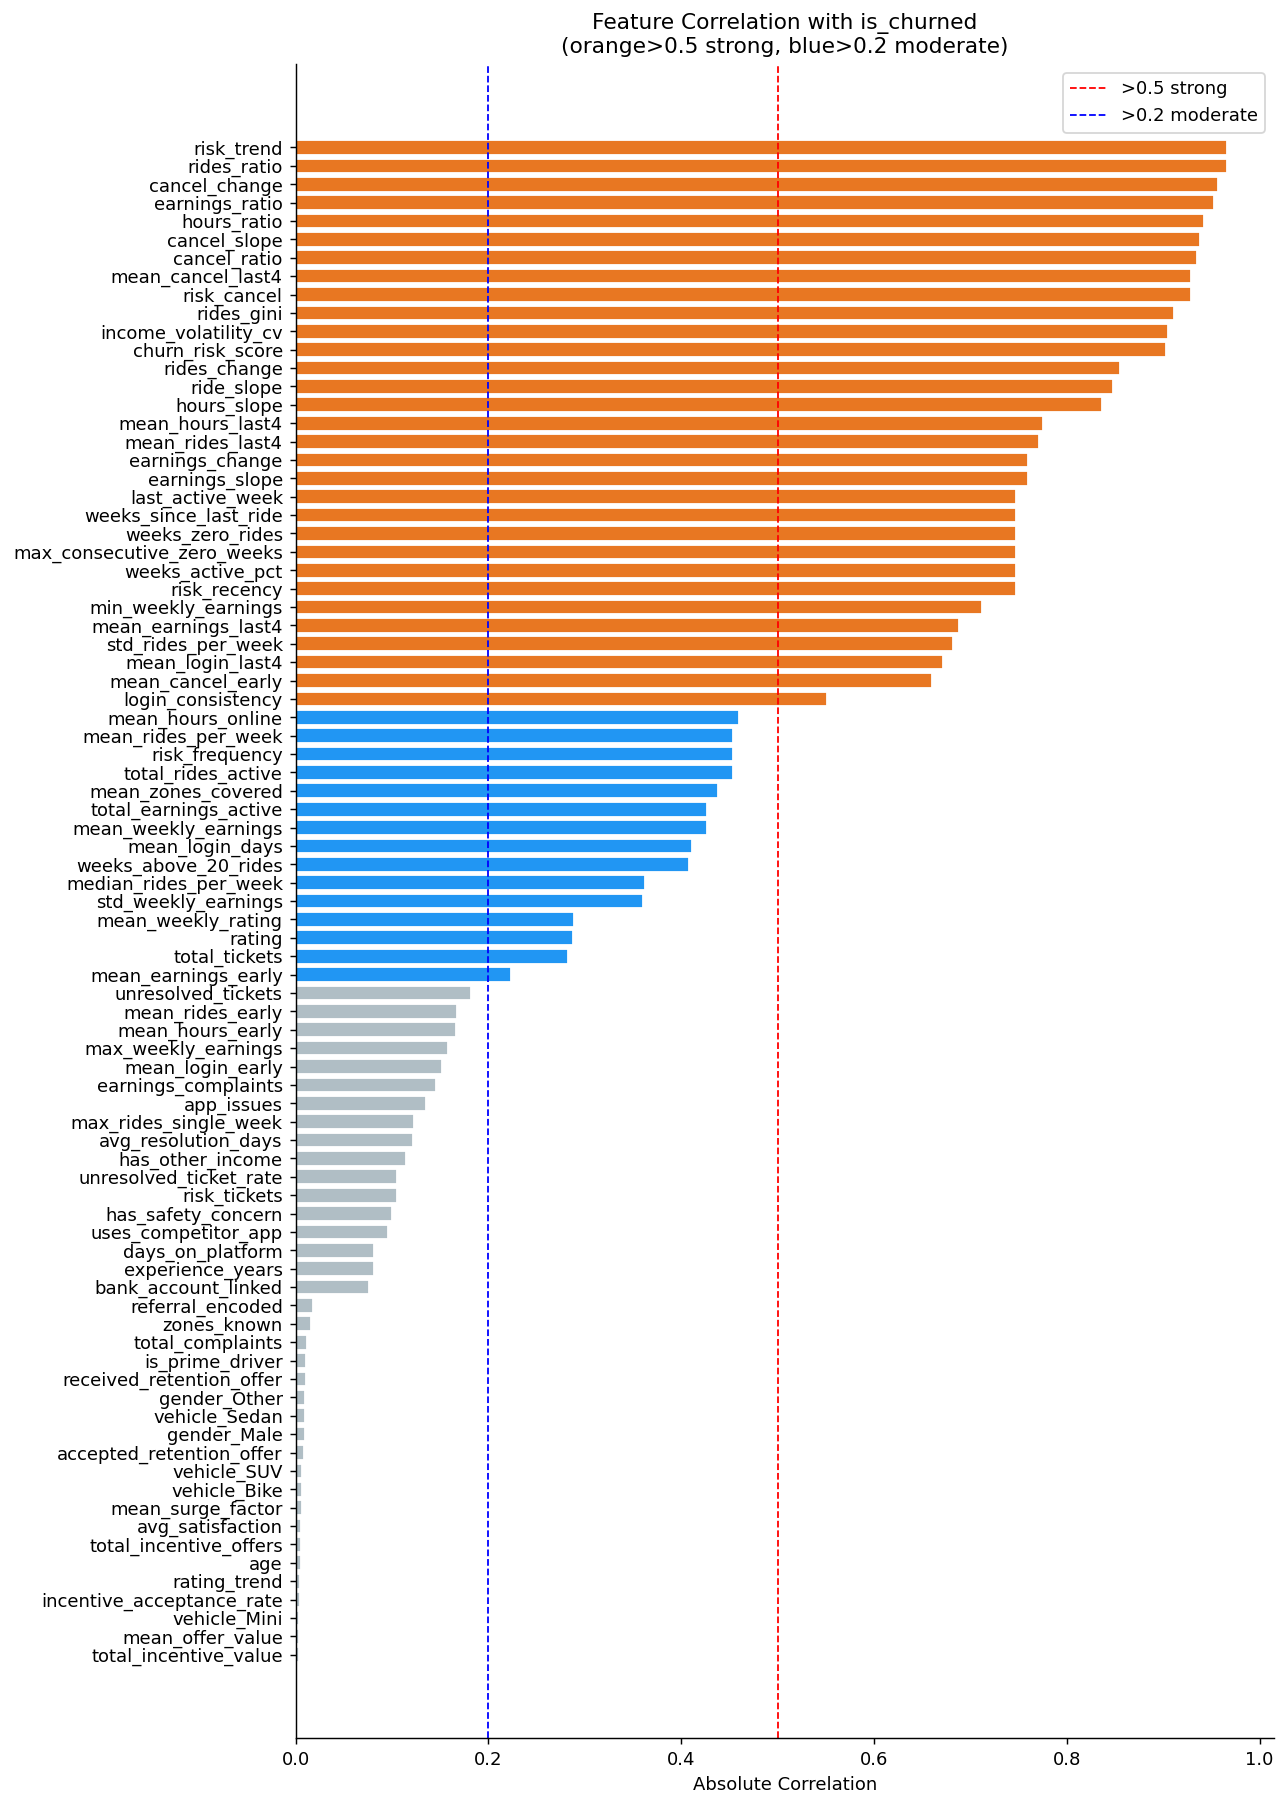

Top 15 features by correlation with is_churned:
risk_trend             0.9667
rides_ratio            0.9667
cancel_change          0.9570
earnings_ratio         0.9531
hours_ratio            0.9421
cancel_slope           0.9383
cancel_ratio           0.9354
mean_cancel_last4      0.9290
risk_cancel            0.9290
rides_gini             0.9111
income_volatility_cv   0.9049
churn_risk_score       0.9027
rides_change           0.8557
ride_slope             0.8476
hours_slope            0.8362
dtype: float64

Features with correlation > 0.5: 31
Features with correlation > 0.2: 46
Features with correlation < 0.05: 20 (low signal — consider dropping)


In [16]:
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 14))
colors = [
    "#E87722" if v > 0.5 else
    "#2196F3" if v > 0.2 else
    "#B0BEC5"
    for v in corr_with_target.values
]
ax.barh(corr_with_target.index, corr_with_target.values,
        color=colors, edgecolor="white")
ax.set_title(
    "Feature Correlation with is_churned\n"
    "(orange>0.5 strong, blue>0.2 moderate)",
    fontsize=12
)
ax.set_xlabel("Absolute Correlation")
ax.invert_yaxis()
ax.axvline(0.5, color="red", linestyle="--",
           linewidth=1, label=">0.5 strong")
ax.axvline(0.2, color="blue", linestyle="--",
           linewidth=1, label=">0.2 moderate")
ax.legend()

plt.tight_layout()
plt.savefig("../data/processed/fe_01_feature_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Top 15 features by correlation with is_churned:")
print(corr_with_target.head(15).round(4))
print(f"\nFeatures with correlation > 0.5: "
      f"{(corr_with_target > 0.5).sum()}")
print(f"Features with correlation > 0.2: "
      f"{(corr_with_target > 0.2).sum()}")
print(f"Features with correlation < 0.05: "
      f"{(corr_with_target < 0.05).sum()} "
      f"(low signal — consider dropping)")

In [17]:
import os
os.makedirs(PATH, exist_ok=True)

# Save full modeling dataset
modeling_dataset = X.copy()
modeling_dataset["is_churned"] = y.values
modeling_dataset["driver_id"] = modeling_df.loc[
    valid_mask, "driver_id"
].values

modeling_dataset.to_csv(
    PATH + "modeling_data.csv", index=False
)

# Save feature list
with open(PATH + "feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

# Compute and save class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    "balanced", classes=np.array([0, 1]), y=y
)
class_weight_dict = dict(zip([0, 1], class_weights))

with open(PATH + "class_weights.pkl", "wb") as f:
    pickle.dump(class_weight_dict, f)

print("✅ Saved to data/processed/")
print(f"  modeling_data.csv : "
      f"{len(modeling_dataset):,} rows × "
      f"{len(modeling_dataset.columns)} columns")
print(f"  feature_cols.pkl  : {len(feature_cols)} features")
print(f"  class_weights.pkl : {class_weight_dict}")

✅ Saved to data/processed/
  modeling_data.csv : 5,000 rows × 85 columns
  feature_cols.pkl  : 83 features
  class_weights.pkl : {0: np.float64(0.8375209380234506), 1: np.float64(1.2406947890818858)}
